In [1]:
import sys
sys.path.append('../onitama/')
from trainer import RegularDataTrainer
from dl_players_v7 import DensePlayer_v7
import numpy as np
from livelossplot import PlotLossesKeras
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

2026-03-23 21:18:56.885225: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-23 21:18:56.902194: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-23 21:18:57.517308: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-23 21:18:59.599644: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computat

In [2]:
#Configuration

folder_data = "../data/v6b/"

In [3]:
def action_to_one_hot(action, shape=(5, 5, 52)):
    """
    Convertit une action [col, ligne, action_id] en one-hot tensor
    
    Args:
        action: [col, ligne, action_id] ou liste d'actions (batch)
        shape: (height, width, n_actions)
        
    Returns:
        one_hot: (5, 5, 52) ou (batch, 5, 5, 52)
    """
    if isinstance(action, list) and len(action) == 3:
        # Une seule action
        col, ligne, action_id = action
        one_hot = np.zeros(shape, dtype=np.float32)
        one_hot[col, ligne, action_id] = 1.0
        return one_hot
    else:
        # Batch d'actions
        batch_size = len(action)
        one_hot_batch = np.zeros((batch_size, *shape), dtype=np.float32)
        
        for i, act in enumerate(action):
            col, ligne, action_id = act
            one_hot_batch[i, col, ligne, action_id] = 1.0
        
        return one_hot_batch

def flat_index_to_action(flat_index):
    """
    Convertit index flat [0, 1299] en [col, ligne, move_id]
    """
    col = flat_index // (5 * 52)
    ligne = (flat_index // 52) % 5
    move_id = flat_index % 52
    return col, ligne, move_id


def decode_flat_policy(flat_policy):
    """
    Décode un vecteur aplati (1300,) en [col, ligne, move_id]
    
    Args:
        flat_policy: array de shape (1300,) - one-hot ou probabilités
        
    Returns:
        action: [col, ligne, move_id]
    """
    # 1. Trouver l'index du maximum (ou du 1.0 si one-hot)
    best_index = np.argmax(flat_policy)
    
    # 2. Décoder l'index
    col = best_index // (5 * 52)
    ligne = (best_index // 52) % 5
    move_id = best_index % 52
    
    return [int(col), int(ligne), int(move_id)]

def old_one_hot_to_action(action, verbose=False):
    """
    Convertit un one-hot tensor en action [col, ligne, move_id]
    
    Args:
        action: (5, 5, 52) ou (batch, 5, 5, 52)
        verbose: afficher les détails
        
    Returns:
        (col, ligne, move_id) ou liste de (col, ligne, move_id)
    """
    action = np.array(action)
    
    # Déterminer si c'est un batch ou une action seule
    if action.ndim == 3:
        # Une seule action (5, 5, 52)
        flat_logits = action.reshape(-1)
        
        exp_logits = np.exp(flat_logits - np.max(flat_logits))
        probabilities = exp_logits / exp_logits.sum()
        
        best_flat = np.argmax(probabilities)
        best_col, best_ligne, best_move_id = flat_index_to_action(best_flat)
        
        if verbose:
            print(f"Probabilités : {probabilities.shape}, sum={probabilities.sum():.3f}")
            print(f"Meilleure action : [{best_col}, {best_ligne}, {best_move_id}]")
            print(f"Probabilité : {probabilities[best_flat]:.4f}")
        
        return (best_col, best_ligne, best_move_id)
    
    elif action.ndim == 4:
        # Batch d'actions (batch, 5, 5, 52)
        batch_size = action.shape[0]
        results = []
        
        for i in range(batch_size):
            flat_logits = action[i].reshape(-1)
            
            exp_logits = np.exp(flat_logits - np.max(flat_logits))
            probabilities = exp_logits / exp_logits.sum()
            
            best_flat = np.argmax(probabilities)
            best_col, best_ligne, best_move_id = flat_index_to_action(best_flat)
            
            if verbose:
                print(f"[{i}] Probabilités : {probabilities.shape}, sum={probabilities.sum():.3f}")
                print(f"[{i}] Meilleure action : [{best_col}, {best_ligne}, {best_move_id}]")
                print(f"[{i}] Probabilité : {probabilities[best_flat]:.4f}")
            
            results.append((best_col, best_ligne, best_move_id))
        
        return results
    
    else:
        raise ValueError(f"Action doit avoir 3 ou 4 dimensions, reçu {action.ndim}")

In [4]:
#Récupération des données
import glob
import os


# Scanner le dossier et grouper par préfixe (nom de base sans suffixe)
states_files = sorted(glob.glob(os.path.join(folder_data, "*.states.pkl")))
basenames = [os.path.basename(f).replace(".states.pkl", "") for f in states_files]

policy_files = [os.path.join(folder_data, f"{b}.labels.pkl") for b in basenames]
mask_files   = [os.path.join(folder_data, f"{b}.mask.pkl")   for b in basenames]

# Vérifier que tous les fichiers existent
for s, p, m in zip(states_files, policy_files, mask_files):
    for path in [s, p, m]:
        if not os.path.exists(path):
            print(f"⚠️  Fichier manquant : {path}")

print(f"{len(basenames)} jeu(x) de données trouvé(s) :")
for b in basenames:
    print(f"  - {b}")

states = []
policies = []
masks = []

for s_file, p_file, m_file in zip(states_files, policy_files, mask_files):
    states   += RegularDataTrainer.getTrainedData(filepath=s_file)
    policies += RegularDataTrainer.getTrainedData(filepath=p_file)
    masks    += RegularDataTrainer.getTrainedData(filepath=m_file)
    print(f"Chargé : {os.path.basename(s_file)}")

print("\n\nTotal :")
print(f"{len(states)} states")
print(f"{len(policies)} policies")
print(f"{len(masks)} masks")
print(f"{len(policies) / 21} games (approx.)")

# Filtrer les entrées dont le state n'a pas la shape attendue (10, 5, 5)
EXPECTED_SHAPE = (10, 5, 5)
valid = [np.array(s).shape == EXPECTED_SHAPE for s in states]
n_invalid = sum(1 for v in valid if not v)
if n_invalid > 0:
    print(f"⚠️  {n_invalid} états ignorés (shape incorrecte)")
    states   = [s for s, v in zip(states,   valid) if v]
    policies = [p for p, v in zip(policies, valid) if v]
    masks    = [m for m, v in zip(masks,    valid) if v]

states = np.array(states)
print(states.shape)

#On est en (10, 5, 5) le réseau attend du (5, 5, 10) il faut transposer
states = np.transpose(states, (0, 2, 3, 1))
print(states.shape) #Maintenant on est bien (en 5,5,10)

6 jeu(x) de données trouvé(s) :
  - LookAheadHeuristic3heuristic_aggressive-vs-LookAheadHeuristic2heuristic_defensive
  - LookAheadHeuristic3heuristic_aggressive-vs-LookAheadHeuristic2heuristic_regular
  - LookAheadHeuristic3heuristic_defensive-vs-LookAheadHeuristic2heuristic_aggressive
  - LookAheadHeuristic3heuristic_defensive-vs-LookAheadHeuristic2heuristic_mobility
  - LookAheadHeuristic3heuristic_defensive-vs-LookAheadHeuristic2heuristic_positional
  - LookAheadHeuristic3heuristic_defensive-vs-LookAheadHeuristic2heuristic_regular
Chargé : LookAheadHeuristic3heuristic_aggressive-vs-LookAheadHeuristic2heuristic_defensive.states.pkl
Chargé : LookAheadHeuristic3heuristic_aggressive-vs-LookAheadHeuristic2heuristic_regular.states.pkl
Chargé : LookAheadHeuristic3heuristic_defensive-vs-LookAheadHeuristic2heuristic_aggressive.states.pkl
Chargé : LookAheadHeuristic3heuristic_defensive-vs-LookAheadHeuristic2heuristic_mobility.states.pkl
Chargé : LookAheadHeuristic3heuristic_defensive-vs-Look

In [5]:

#On applique one Hot Encoder sur les actions (policies)
policies = action_to_one_hot(policies)




In [6]:

#Aplatir pour correspondre à la sortie du modèle
policies = policies.reshape(-1, 5 * 5 * 52)  # (batch, 1300)




In [7]:
#Concatner avec les masques
masks = np.array(masks, dtype=np.float32)
y_masked = np.concatenate([policies, masks], axis=1)

In [8]:
# Fix: shuffle en place AVANT validation_split (sans copie mémoire)
# np.random.permutation + fancy indexing crée des copies → OOM sur gros datasets
# Ici on utilise le même RNG avec le même seed pour shuffler les deux tableaux identiquement
seed = np.random.randint(0, 2**31)
rng = np.random.default_rng(seed)
rng.shuffle(states)      # shuffle en place (axe 0)
rng = np.random.default_rng(seed)
rng.shuffle(y_masked)    # même permutation, en place
print(f"Données mélangées : {len(states)} échantillons")

Données mélangées : 474458 échantillons


In [9]:
policies[0]

array([0., 0., 0., ..., 0., 0., 0.], shape=(1300,), dtype=float32)

In [ ]:
network = DensePlayer_v7(dropout_rate=0.2)


2026-03-23 21:19:41.727374: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


In [11]:
# Compiler pour supervised (gèle value head - spécifier d'utiliser les masques pour le calcul de la loss)
network.compile_for_supervised_policy(use_mask=True)

Gelé 3 layers de la tête de valeur
Modèle compilé pour entraînement supervisé (policy seulement, label_smoothing=0.0, weight_decay=0.0001, use_mask=True)


In [12]:
network.summary()

Model: "OnitamaNetwork-v7-Dense"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ state_input         │ (None, 5, 5, 10)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ trunk_flatten       │ (None, 250)       │          0 │ state_input[0][0] │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ trunk_dense_0       │ (None, 512)       │    128,512 │ trunk_flatten[0]… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ trunk_bn_0          │ (None, 512)       │      2,048 │ trunk_dense_0[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ trunk_relu_0        │ (None, 512)       │          0 │ trunk_bn_0[0][0]  │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ trunk_dropout_0     │ (None, 512)       │          0 │ trunk_relu_0[0][… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ trunk_dense_1       │ (None, 512)       │    262,656 │ trunk_dropout_0[… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ trunk_bn_1          │ (None, 512)       │      2,048 │ trunk_dense_1[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ trunk_relu_1        │ (None, 512)       │          0 │ trunk_bn_1[0][0]  │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ trunk_dropout_1     │ (None, 512)       │          0 │ trunk_relu_1[0][… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ trunk_dense_2       │ (None, 256)       │    131,328 │ trunk_dropout_1[… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ trunk_bn_2          │ (None, 256)       │      1,024 │ trunk_dense_2[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ trunk_relu_2        │ (None, 256)       │          0 │ trunk_bn_2[0][0]  │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ trunk_dropout_2     │ (None, 256)       │          0 │ trunk_relu_2[0][… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ value_dense1        │ (None, 64)        │     16,448 │ trunk_dropout_2[… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ policy_dropout      │ (None, 256)       │          0 │ trunk_dropout_2[… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ value_dropout       │ (None, 64)        │          0 │ value_dense1[0][

 Total params: 878,229 (3.35 MB)

 Trainable params: 859,156 (3.28 MB)

 Non-trainable params: 19,073 (74.50 KB)

In [13]:
x_train  = states
y_value  = np.zeros((len(x_train), 1))

In [14]:
y_policy = y_masked[:, :1300]  # conserver séparément pour les évaluations top-k

In [15]:
# Fix: aligner EarlyStopping et ModelCheckpoint sur la même métrique.
# Avant : EarlyStopping surveillait val_loss, ModelCheckpoint surveillait val_policy_logits_accuracy.
# Risque : EarlyStopping pouvait arrêter alors que l'accuracy progressait encore.
early_stop = EarlyStopping(
    monitor='val_policy_logits_accuracy',
    patience=5,
    restore_best_weights=True,
    mode='max'
)

checkpoint = ModelCheckpoint(
    filepath="../saved-models/DensePlayer-v7-best.weights.h5",
    monitor='val_policy_logits_accuracy',
    save_best_only=True,
    save_weights_only=True,
    mode='max',
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_policy_logits_accuracy',
    factor=0.5,
    patience=2,
    min_lr=1e-5,
    mode='max',
    verbose=1
)

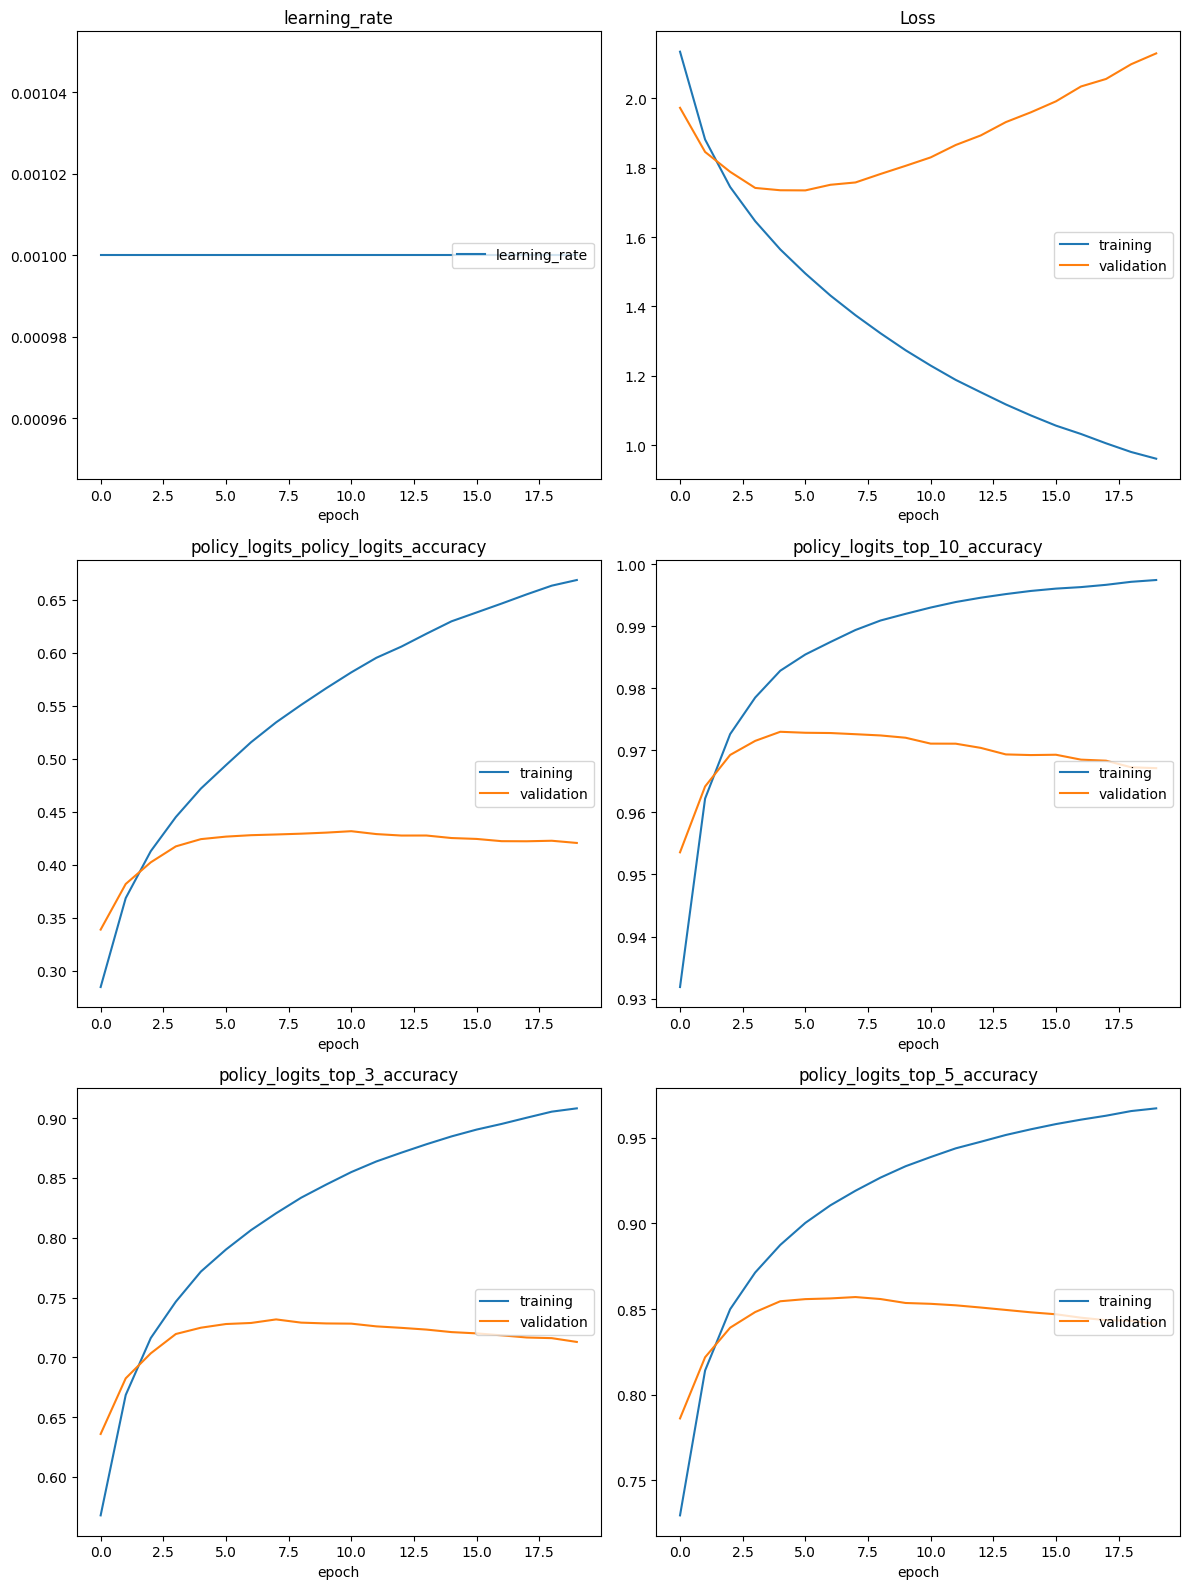

learning_rate
	learning_rate    	 (min:    0.001, max:    0.001, cur:    0.001)
Loss
	training         	 (min:    0.961, max:    2.134, cur:    0.961)
	validation       	 (min:    1.734, max:    2.129, cur:    2.129)
policy_logits_policy_logits_accuracy
	training         	 (min:    0.285, max:    0.669, cur:    0.669)
	validation       	 (min:    0.339, max:    0.432, cur:    0.421)
policy_logits_top_10_accuracy
	training         	 (min:    0.932, max:    0.997, cur:    0.997)
	validation       	 (min:    0.954, max:    0.973, cur:    0.967)
policy_logits_top_3_accuracy
	training         	 (min:    0.568, max:    0.908, cur:    0.908)
	validation       	 (min:    0.636, max:    0.732, cur:    0.713)
policy_logits_top_5_accuracy
	training         	 (min:    0.729, max:    0.967, cur:    0.967)
	validation       	 (min:    0.786, max:    0.857, cur:    0.841)
5931/5931 ━━━━━━━━━━━━━━━━━━━━ 63s 11ms/step - loss: 0.9611 - policy_logits_policy_logits_accuracy: 0.6687 - policy_logits_top_10_

KeyboardInterrupt: 

In [16]:
history = network.fit(
    x_train,
    [y_masked, y_value],
    batch_size=64,
    validation_batch_size=512,
    shuffle=True,  # déjà shufflé manuellement → évite la copie interne par epoch
    epochs=50,
    validation_split=0.2,
    callbacks=[early_stop, checkpoint, reduce_lr, PlotLossesKeras()]
)

In [ ]:
#Sauvegarder les poids
network.save_weights("../saved-models/model-v7-entrainement-supervise.weights.h5")

#Sauvegarder le modèle
network.save("../saved-models/model-v7-entrainement-supervise.keras")

In [ ]:
# === ÉVALUATION TOP-K ACCURACY SUR MODÈLE EXISTANT ===

def evaluate_top_k_accuracy(network, x_data, y_policy, k_values=[1, 3, 5, 10], batch_size=256):
    """
    Évalue les métriques top-k accuracy sur un modèle déjà entraîné.
    
    Args:
        network: Le modèle CNNPlayer
        x_data: États (N, 5, 5, 10)
        y_policy: Policies one-hot (N, 1300)
        k_values: Liste des k pour top-k accuracy
        batch_size: Taille des batchs pour la prédiction
    
    Returns:
        dict avec les accuracies pour chaque k
    """
    n_samples = len(x_data)
    
    # Récupérer les indices des vraies actions
    y_true_indices = np.argmax(y_policy, axis=1)  # (N,)
    
    # Prédire par batch pour éviter les problèmes de mémoire
    all_logits = []
    for i in range(0, n_samples, batch_size):
        batch_x = x_data[i:i+batch_size]
        policy_logits, _ = network.model(batch_x, training=False)
        all_logits.append(policy_logits.numpy())
    
    all_logits = np.concatenate(all_logits, axis=0)  # (N, 1300)
    
    # Calculer top-k accuracy pour chaque k
    results = {}
    for k in k_values:
        # Trouver les top-k indices pour chaque prédiction
        top_k_indices = np.argsort(all_logits, axis=1)[:, -k:]  # (N, k)
        
        # Vérifier si la vraie action est dans le top-k
        correct = np.array([y_true_indices[i] in top_k_indices[i] for i in range(n_samples)])
        accuracy = correct.mean()
        results[f'top_{k}'] = accuracy
    
    return results

# Évaluer sur les données (sans augmentation pour comparaison équitable)
print("Évaluation des métriques top-k sur le modèle actuel...")
print(f"Nombre d'échantillons: {len(x_train)}")
print()

results = evaluate_top_k_accuracy(network, x_train, y_policy)

print("=" * 40)
print("RÉSULTATS TOP-K ACCURACY")
print("=" * 40)
for metric, value in results.items():
    print(f"  {metric}: {value:.2%}")
print("=" * 40)

# Interprétation
print("\nInterprétation:")
if results['top_5'] >= 0.7:
    print("✓ Le modèle place généralement les bons coups dans le top 5")
elif results['top_5'] >= 0.5:
    print("~ Performance moyenne - le modèle a une certaine compréhension")
else:
    print("✗ Performance faible - problème de données ou d'architecture")

In [ ]:

def predict_action(network, state, deterministic=True, valid_actions_mask=None):
    """
    Prédit une action à partir d'un état
    
    Args:
        network: Le réseau de neurones
        state: (5, 5, 10) - un état (sans batch dimension)
        deterministic: Si True, prend l'action avec le score max
                      Si False, échantillonne selon les probabilités
        valid_actions_mask: (5, 5, 52) optionnel - masque des actions valides
        
    Returns:
        action: [col, ligne, move_id]
        probability: probabilité de cette action
    """
    # 1. Ajouter la dimension batch si nécessaire
    if len(state.shape) == 3:
        state_batch = np.expand_dims(state, axis=0)  # (1, 5, 5, 10)
    else:
        state_batch = state
    
    # 2. Prédiction
    policy_logits, value = network.predict(state_batch, training=False)
    
    # 3. Retirer la dimension batch
    policy_logits = policy_logits.numpy()
    policy_logits = policy_logits[0]  # (5, 5, 52)
    value = value[0, 0]  # Scalar
    
    # 4. Masquer les actions invalides (optionnel mais IMPORTANT)
    if valid_actions_mask is not None:
        large_negative = -1e9
        masked_logits = np.where(
            valid_actions_mask,
            policy_logits,
            large_negative
        )
    else:
        masked_logits = policy_logits
    
    # 5. Aplatir en (1300,) pour faciliter le traitement
    flat_logits = masked_logits.reshape(-1)  # (5*5*52 = 1300,)
    
    # 6. Convertir en probabilités avec softmax
    flat_probs = softmax(flat_logits)
    
    # 7. Sélectionner l'action
    if deterministic:
        # Prendre l'action avec la probabilité max
        best_index = np.argmax(flat_probs)
    else:
        # Échantillonner selon les probabilités
        best_index = np.random.choice(len(flat_probs), p=flat_probs)
    
    # 8. Décoder l'index en [col, ligne, move_id]
    col = best_index // (5 * 52)
    ligne = (best_index // 52) % 5
    move_id = best_index % 52
    
    action = [int(col), int(ligne), int(move_id)]
    probability = flat_probs[best_index]
    
    return action, probability, value


def softmax(x):
    """Calcule le softmax de manière stable numériquement"""
    exp_x = np.exp(x - np.max(x))  # Soustraire le max pour stabilité
    return exp_x / exp_x.sum()

In [ ]:
#Vérification des prédictions pour les premiers états

for i in range(10):
    # Prédire l'action (déterministe)
    state = x_train[i]
    action_reelle = y_policy[i]
    action, prob, value = predict_action(network, state, deterministic=True)

    print("---------------------")
    print(f"État: {state.shape}")
    print(f"Action prédite: {action}")
    print(f"  → Colonne: {action[0]}")
    print(f"  → Ligne: {action[1]}")
    print(f"  → Mouvement: {action[2]}")
    print(f"Probabilité: {prob:.4f}")

    print(decode_flat_policy(action_reelle))
